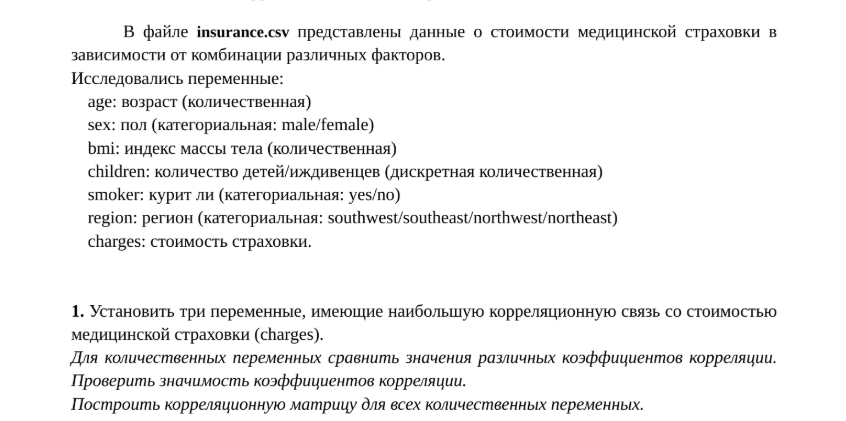

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


,Variable,Normal distributed,Pearson_r,Pearson p-val,Pearson_signif,Spearman_r,Spearman_p-val,Spearman_signif,Kendall_tau,Kendall_p-val,Kendall_signif
0,age,False,"[0.29900819333064765, 0.29900819333064754]","[None, None]","[Pass, Pass]","[0.534392133771846, 0.5343921337718459]","[1.130692027803348e-99, 1.130692027803638e-99]","[True, True]","[0.4807427927010872, 0.47530235429087664]","[3.67600785428456e-153, 2.589078641444977e-146]","[True, True]"
1,bmi,False,"[0.19834096883362887, 0.19834096883362887]","[None, None]","[Pass, Pass]","[0.11939590358331145, 0.11939590358331145]","[1.1926059544526762e-05, 1.1926059544526874e-05]","[True, True]","[0.08260648439617953, 0.08252397079981415]","[5.900660021123463e-06, 6.256900640955888e-06]","[True, True]"
2,children,False,"[0.0679982268479048, 0.0679982268479048]","[None, None]","[Pass, Pass]","[0.13333894319168216, 0.13333894319168216]","[9.846806132997293e-07, 9.846806132997293e-07]","[True, True]","[0.12224637237013533, 0.10310682138766059]","[2.032586896690792e-11, 5.029616382784502e-07]","[True, True]"


smoker_norm    0.787251
age            0.299008
bmi            0.198341
Name: charges, dtype: float64

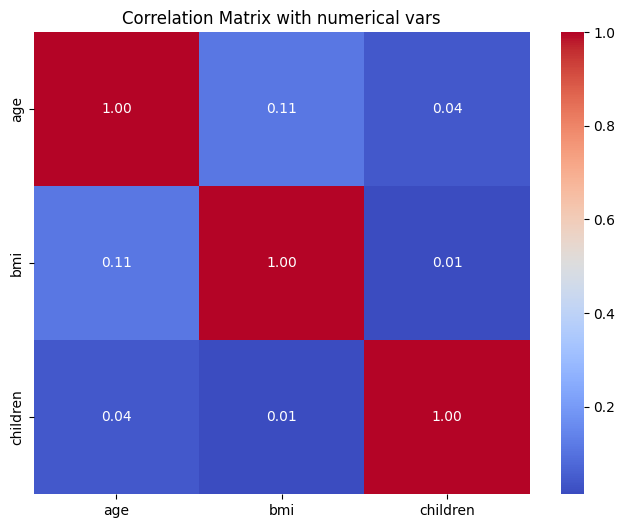

In [8]:
# 1.1 Variables setup
from chi_square import check_normality_chi2


numerical_vars = ["age", "bmi", "children"]
target = "charges"

alpha = 0.05  # Significance level
n = len(df)

corr_results = []


def calculate_pearson(x, y, can_check_critical):
    # Manual calcs
    x_mean = x.mean()
    y_mean = y.mean()
    sum_sq_x = ((x - x_mean) ** 2).sum()
    sum_sq_y = ((y - y_mean) ** 2).sum()
    denominator = np.sqrt(sum_sq_x * sum_sq_y)
    numerator = ((x - x_mean) * (y - y_mean)).sum()

    manual_r = numerator / denominator

    degrees_of_freedom = n - 2
    z_stat = (manual_r * np.sqrt(degrees_of_freedom)) / np.sqrt(1 - manual_r**2)
    manual_p_val = stats.t.sf(np.abs(z_stat), degrees_of_freedom) * 2

    # Lib calcs
    lib_r, lib_p_val = stats.pearsonr(df[var], df[target])

    if can_check_critical:
        return (manual_r, lib_r, manual_p_val, lib_p_val)

    else:
        return manual_r, lib_r, None, None


def calculate_spearman(x, y):
    x_rank = x.rank(method="average")
    y_rank = y.rank(method="average")

    man_r, _, man_p, _ = calculate_pearson(x_rank, y_rank, True)
    lib_r, lib_p = stats.spearmanr(
        x,
        y,
    )

    # z_stat = man_r * np.sqrt(n - 1)
    # man_p = stats.norm.pdf(z_stat)

    return man_r, lib_r, man_p, lib_p


def calculate_kendall(x, y):
    rank_x = x.rank(method="average").values
    rank_y = y.rank(method="average").values
    n = len(rank_x)

    concordant = 0
    discordant = 0

    for i in range(n):
        for j in range(i + 1, n):
            diff_x = rank_x[i] - rank_x[j]
            diff_y = rank_y[i] - rank_y[j]

            product = diff_x * diff_y

            if product > 0:
                concordant += 1
            elif product < 0:
                discordant += 1

    if (concordant + discordant) == 0:
        return 0, 0, 0, 0

    man_tau = (concordant - discordant) / (concordant + discordant)

    z_stat = man_tau * np.sqrt((9 * n * (n + 1)) / (2 * (2 * n + 5)))
    man_p = stats.norm.sf(np.abs(z_stat)) * 2

    lib_tau, lib_p = stats.kendalltau(df[var], df[target])

    return man_tau, lib_tau, man_p, lib_p


can_check_critical_target = check_normality_chi2(df[target])
for var in numerical_vars:
    can_check_critical = check_normality_chi2(df[var]) and can_check_critical_target

    # Pearson (Numerical)
    pearson_man_r, pearson_lib_r, pearson_man_p, pearson_lib_p = calculate_pearson(
        df[var], df[target], can_check_critical
    )

    # Spearman (Rank)
    spearman_man_r, spearman_lib_r, spearman_man_p, spearman_lib_p = calculate_spearman(
        df[var], df[target]
    )

    man_tau, lib_tau, kendall_man_p, kendall_lib_p = calculate_kendall(
        df[var], df[target]
    )

    corr_results.append(
        {
            "Variable": var,
            "Normal distributed": can_check_critical,
            "Pearson_r": [pearson_man_r, pearson_lib_r],
            "Pearson p-val": [pearson_man_p, pearson_lib_p],
            "Pearson_signif": [
                f"{pearson_man_p < alpha if pearson_man_p else "Pass"}",
                f"{pearson_lib_p < alpha if pearson_lib_p else "Pass"}",
            ],
            "Spearman_r": [spearman_man_r, spearman_lib_r],
            "Spearman_p-val": [spearman_man_p, spearman_lib_p],
            "Spearman_signif": [spearman_man_p < alpha, spearman_lib_p < alpha],
            "Kendall_tau": [man_tau, lib_tau],
            "Kendall_p-val": [kendall_man_p, kendall_lib_p],
            "Kendall_signif": [kendall_man_p < alpha, kendall_lib_p < alpha],
        }
    )

corr_df = pd.DataFrame(corr_results)
display(corr_df)

# Find top-3 correlations
df_encoded = df.copy()
df_encoded["smoker_norm"] = df_encoded["smoker"].map({"yes": 1, "no": 0})
df_encoded["sex_norm"] = df_encoded["sex"].map({"male": 1, "female": 0})
correlations = (
    df_encoded.corr(numeric_only=True)["charges"].abs().sort_values(ascending=False)
)
top_3_features = correlations.iloc[1:4]

display(top_3_features)

# 1.4 Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numerical_vars].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix with numerical vars")
plt.show()

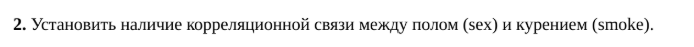

In [ ]:
# 2.1 Create a contingency table
contingency_table = pd.crosstab(df["sex"], df["smoker"])
print("Contingency Table: Sex vs Smoker")
display(contingency_table)

# 2.2 Perform Chi-Square Test
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n--- Chi-Square Test Results ---")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_chi:.4f}")
print(f"Significant relationship: {p_chi < 0.05}")

Contingency Table: Sex vs Smoker


smoker,no,yes
sex,,
female,547,115
male,517,159



--- Chi-Square Test Results ---
Chi-square statistic: 7.3929
P-value: 0.0065
Cramer's V: 0.0743
Significant relationship: True


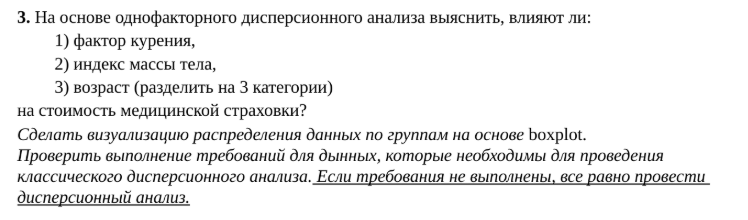

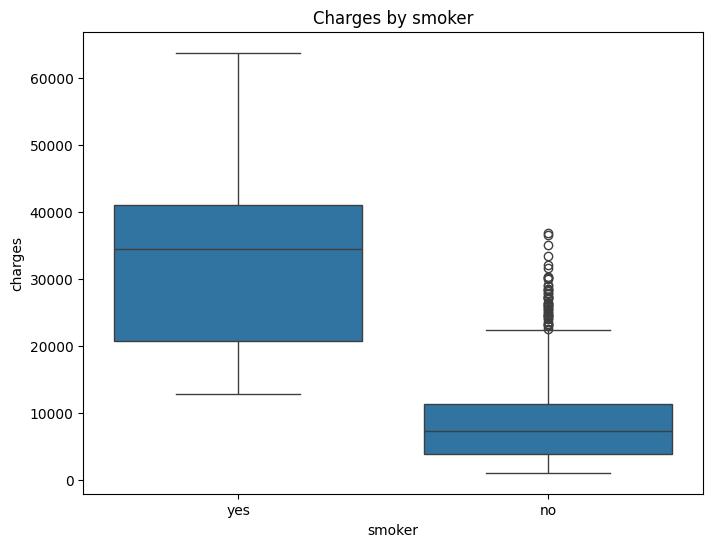

Factor: smoker, Group: yes | Normal: False
Factor: smoker, Group: no | Normal: False
Levene Test (smoker): H1 True: Stat=332.6135, p-value=1.5593e-66
ANOVA (smoker): F-stat=2177.6149, p-value=8.2714e-283
Significant influence lib: True
Significant influence manual: True
------------------------------


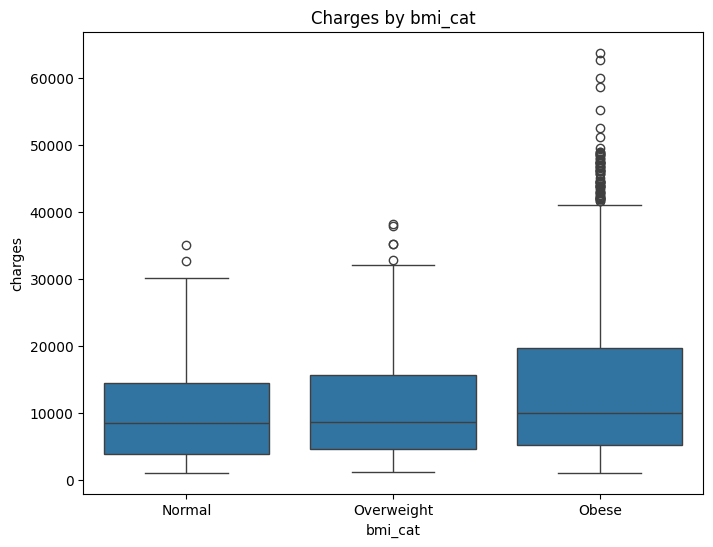

Factor: bmi_cat, Group: Overweight | Normal: False
Factor: bmi_cat, Group: Obese | Normal: False
Factor: bmi_cat, Group: Normal | Normal: False
Levene Test (bmi_cat): H1 True: Stat=33.1644, p-value=8.7753e-15
ANOVA (bmi_cat): F-stat=28.0041, p-value=1.2195e-12
Significant influence lib: True
Significant influence manual: True
------------------------------


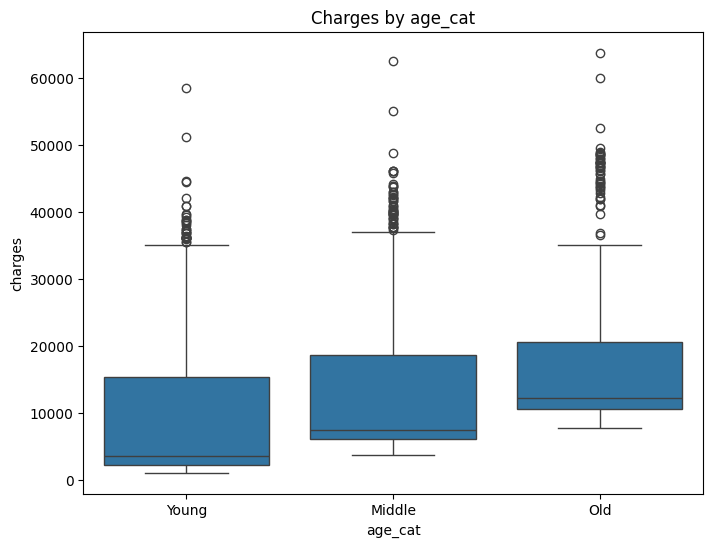

Factor: age_cat, Group: Young | Normal: False
Factor: age_cat, Group: Middle | Normal: False
Factor: age_cat, Group: Old | Normal: False
Levene Test (age_cat): H1 False: Stat=0.1678, p-value=8.4553e-01
ANOVA (age_cat): F-stat=52.4487, p-value=1.1815e-22
Significant influence lib: True
Significant influence manual: True
------------------------------


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols


def check_factor_influence(groups_data, n, k, alpha=0.05):
    """
    H0: M[Y1] = M[Y2] = ... = M[Yk]
    """
    overall_mean = np.mean(np.concatenate(groups_data))

    # S2_X: Intergroup variance
    s2_x = sum(len(g) * (np.mean(g) - overall_mean) ** 2 for g in groups_data) / (k - 1)

    # S2_O: Intragroup (residual) variance
    s2_o = sum(sum((g - np.mean(g)) ** 2) for g in groups_data) / (n - k)

    # Z-statistic (F-stat)
    z_stat = s2_x / s2_o

    # Critical value Z_kp
    z_kp = stats.f.ppf(1 - alpha, k - 1, n - k)


    return z_stat, z_kp


df["age_cat"] = pd.qcut(df["age"], 3, labels=["Young", "Middle", "Old"])
df["bmi_cat"] = pd.cut(
    df["bmi"], bins=[0, 25, 30, 100], labels=["Normal", "Overweight", "Obese"]
)
factors = ["smoker", "bmi_cat", "age_cat"]

for factor in factors:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=factor, y="charges", data=df)
    plt.title(f"Charges by {factor}")
    plt.show()

    groups_data = []
    unique_groups = df[factor].unique()

    # Step 1: Normality per group
    for g in unique_groups:
        group_charges = df[df[factor] == g]["charges"]
        groups_data.append(group_charges)
        is_normal = check_normality_chi2(group_charges)
        print(f"Factor: {factor}, Group: {g} | Normal: {is_normal}")

    # Step 2: Levene's Test (Homogeneity of variance)
    stat_l, p_l = stats.levene(*groups_data)
    print(f"Levene Test ({factor}): H1 {p_l < 0.05}: Stat={stat_l:.4f}, p-value={p_l:.4e}")

    # Step 3: One-way ANOVA
    # Calculating F-statistic (Z on slide)
    z_stat, z_kp = check_factor_influence(groups_data, len(df), len(groups_data))
    f_stat, p_anova = stats.f_oneway(*groups_data)
    print(f"ANOVA ({factor}): F-stat={f_stat:.4f}, p-value={p_anova:.4e}")
    print(f"Significant influence lib: {p_anova < 0.05}")
    print(f"Significant influence manual: {z_stat > z_kp}")
    print("-" * 30)

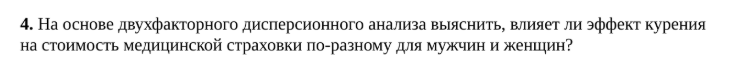

--- Two-Way ANOVA Table ---
                        sum_sq      df            F         PR(>F)
C(sex)            1.421312e+06     1.0     0.025601   8.729026e-01
C(smoker)         1.208777e+11     1.0  2177.284440  1.247285e-282
C(sex):C(smoker)  4.923397e+08     1.0     8.868165   2.954255e-03
Residual          7.406056e+10  1334.0          NaN            NaN


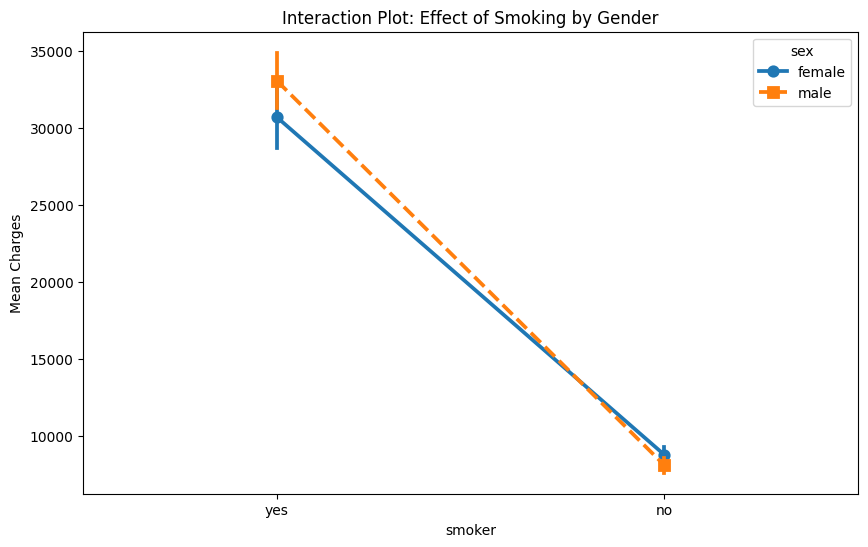

In [13]:
# 4.1 Define the model
# 'charges ~ C(sex) * C(smoker)' means we look at:
# 1. Main effect of sex
# 2. Main effect of smoker
# 3. Interaction effect (sex * smoker)
model = ols("charges ~ C(sex) * C(smoker)", data=df).fit()

# 4.2 Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print("--- Two-Way ANOVA Table ---")
print(anova_table)

# 4.3 Visualization: Interaction Plot
# This plot shows if the lines for male/female are parallel.
# If they cross or have different slopes, there is an interaction.
plt.figure(figsize=(10, 6))
sns.pointplot(
    x="smoker",
    y="charges",
    hue="sex",
    data=df,
    markers=["o", "s"],
    linestyles=["-", "--"],
)
plt.title("Interaction Plot: Effect of Smoking by Gender")
plt.ylabel("Mean Charges")
plt.show()